<a href="https://colab.research.google.com/github/gadekarvishal08-cloud/IN226005202_NLP/blob/main/Task_4_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
!pip uninstall -y peft wandb -q
!pip install transformers==4.40.0 datasets scikit-learn torch -q

In [27]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

In [28]:
dataset = load_dataset("imdb")

In [29]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

dataset = dataset.map(lambda x: {"text": clean_text(x["text"])})

In [30]:
train_test = dataset["train"].train_test_split(test_size=0.1)

train_dataset = train_test["train"]
val_dataset = train_test["test"]
test_dataset = dataset["test"]

In [31]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

In [32]:
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

In [33]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [34]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    report_to="none"   # ✅ avoids wandb issues
)

In [35]:
def compute_metrics(pred):
    logits, labels = pred
    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary'
    )
    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [36]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

In [37]:
trainer.train()

Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.288500,0.338752,0.910400,0.908943,0.929343,0.889419
2,0.169600,0.382547,0.913200,0.913442,0.916000,0.910899


TrainOutput(global_step=5626, training_loss=0.2523859592251959, metrics={'train_runtime': 2411.47, 'train_samples_per_second': 18.661, 'train_steps_per_second': 2.333, 'total_flos': 5919998745600000.0, 'train_loss': 0.2523859592251959, 'epoch': 2.0})

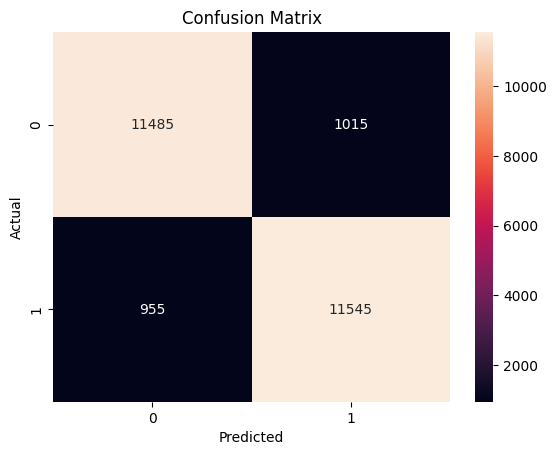

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)

cm = confusion_matrix(predictions.label_ids, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [39]:
for param in model.bert.parameters():
    param.requires_grad = False

In [40]:
for name, param in model.bert.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

In [41]:
training_args = TrainingArguments(
    output_dir="./results_exp2",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    report_to="none"
)

In [42]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

In [43]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.063200,0.409048,0.914000,0.914034,0.918810,0.909308
2,0.094200,0.380941,0.912800,0.913355,0.912629,0.914081


TrainOutput(global_step=5626, training_loss=0.06801697981556751, metrics={'train_runtime': 1167.3412, 'train_samples_per_second': 38.549, 'train_steps_per_second': 4.819, 'total_flos': 5919998745600000.0, 'train_loss': 0.06801697981556751, 'epoch': 2.0})

In [44]:
trainer.evaluate(test_dataset)

{'eval_loss': 0.3420355021953583,
 'eval_accuracy': 0.91864,
 'eval_f1': 0.9189899633582922,
 'eval_precision': 0.9150539340101523,
 'eval_recall': 0.92296,
 'eval_runtime': 444.6985,
 'eval_samples_per_second': 56.218,
 'eval_steps_per_second': 7.027,
 'epoch': 2.0}

In [45]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [46]:
for param in model.bert.parameters():
    param.requires_grad = False

In [47]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.669100,0.658601,0.684000,0.710198,0.658952,0.770088
2,0.659500,0.651745,0.669200,0.718612,0.627824,0.840095


TrainOutput(global_step=5626, training_loss=0.6695008452490391, metrics={'train_runtime': 933.5961, 'train_samples_per_second': 48.201, 'train_steps_per_second': 6.026, 'total_flos': 5919998745600000.0, 'train_loss': 0.6695008452490391, 'epoch': 2.0})

Full fine-tuning of BERT achieved the highest performance with an accuracy of around 91%. Fine-tuning only the last two layers produced nearly identical results with reduced training time, making it an efficient alternative. Freezing the entire BERT model resulted in a significant drop in performance, demonstrating the importance of adapting pre-trained representations to the specific dataset.